## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc)
dataset_monthly

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,23.812763,38.047451,1,2010,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,8.761039,11.580251,5.941828,0.578889,17.782222,10.733185,NaN,NaN,NaN,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,120.039680,25.307650,42.361009,47.792020,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN,2164.888889,0,14600.648385,292.022047,2,182.342684,228.131012,182.543294,0.0,41.287682,32,98,9,99.0,30,98,13,13,10,8,9,2,0
1,23.685082,38.018504,1,2010,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,10.493728,13.860538,7.126918,1.052222,19.014444,12.935874,NaN,NaN,NaN,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,112.130405,23.686240,39.818155,44.482084,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN,2596.888889,0,7655.023708,1575.096836,1,173.398830,66.866135,178.818040,0.0,5.887334,1,98,9,99.0,1,98,13,13,10,8,9,2,0
2,23.754944,37.979104,1,2010,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,9.753346,12.876044,6.630647,0.379474,18.605789,11.901135,NaN,NaN,NaN,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,112.993420,23.831676,39.924151,44.652948,64868.0,377784.0,79042.0,521694.0,61544.0,388717.0,118883.0,569144.0,39021.83,NaN,NaN,2375.526316,0,9967.604261,2195.498040,15,239.898712,262.905206,194.363331,0.0,2.669538,22,89,9,NaN,20,89,13,13,10,8,9,2,9
3,23.749555,37.914897,1,2010,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,9.072484,12.310000,5.834968,-2.668000,19.224000,11.720357,NaN,NaN,NaN,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,110.246915,23.460094,39.829571,44.335911,38993.0,183267.0,41033.0,263293.0,36789.0,199070.0,55549.0,291408.0,12606.74,NaN,NaN,2468.400000,0,2801.690321,1232.926967,4,211.997473,80.771234,191.138144,0.0,3.315736,32,97,9,99.0,30,97,13,13,10,8,9,2,0
4,23.889386,38.042726,1,2010,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,19.416667,21.000000,47.727273,

<AxesSubplot:>

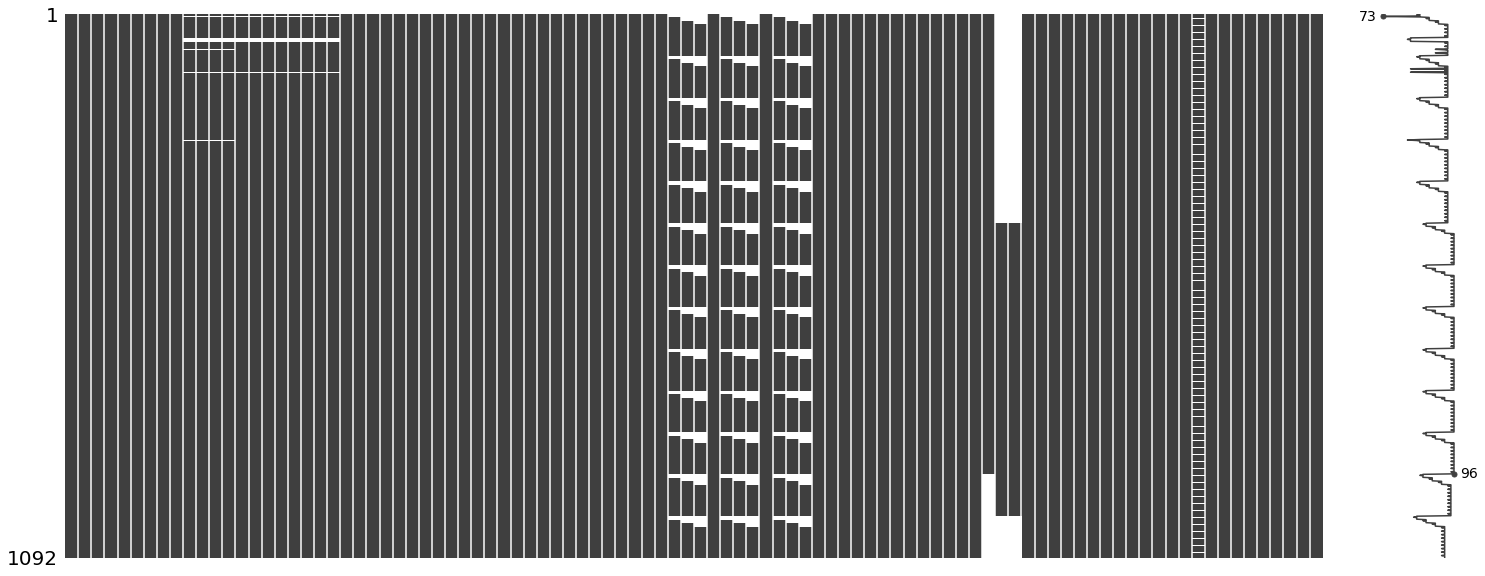

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,1.2821
1,ndmi,1.2821
2,ndwi,1.2821
3,ndbi,1.2821
4,ndvi_mean,1.0073
...,...,...
20,lst_apr_night_mean,25.0000
21,MIO_EUR,15.3846
22,L_TOTAL,46.1538
23,UNL_TOTAL,46.1538


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_NAME.unique()

In [7]:
data = []

for year in years:
    for region in nuts3_units:
        filtered_df = dataset_monthly.loc[(dataset_monthly['year'] == year) & (dataset_monthly['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        q1_df = filtered_df.loc[(filtered_df['month'] <= 3)]
        q2_df = filtered_df.loc[(filtered_df['month'] <= 6)]
        q3_df = filtered_df.loc[(filtered_df['month'] <= 9)]
        q4_df = filtered_df.loc[(filtered_df['month'] <= 12)]

        min_temp_q1 = q1_df['lst'].min()
        mean_temp_q1 = q1_df['lst'].mean()
        max_temp_q1 = q1_df['lst'].max()
        prec_q1 = q1_df['rainfall'].sum()

        ndvi_q1 = q1_df['ndvi'].mean()
        ndwi_q1 = q1_df['ndwi'].mean()
        ndmi_q1 = q1_df['ndmi'].mean()
        ndbi_q1 = q1_df['ndbi'].mean()

        ndvi_mean_q1 = q1_df['ndvi_mean'].mean()
        ndwi_mean_q1 = q1_df['ndwi_mean'].mean()
        ndmi_mean_q1 = q1_df['ndmi_mean'].mean()
        ndbi_mean_q1 = q1_df['ndbi_mean'].mean()

        ndvi_std_q1 = q1_df['ndvi_std'].mean()
        ndwi_std_q1 = q1_df['ndwi_std'].mean()
        ndmi_std_q1 = q1_df['ndmi_std'].mean()
        ndbi_std_q1 = q1_df['ndbi_std'].mean()

        min_temp_q2 = q2_df['lst'].min()
        mean_temp_q2 = q2_df['lst'].mean()
        max_temp_q2 = q2_df['lst'].max()
        prec_q2 = q2_df['rainfall'].sum()

        ndvi_q2 = q2_df['ndvi'].mean()
        ndwi_q2 = q2_df['ndwi'].mean()
        ndmi_q2 = q2_df['ndmi'].mean()
        ndbi_q2 = q2_df['ndbi'].mean()

        ndvi_mean_q2 = q2_df['ndvi_mean'].mean()
        ndwi_mean_q2 = q2_df['ndwi_mean'].mean()
        ndmi_mean_q2 = q2_df['ndmi_mean'].mean()
        ndbi_mean_q2 = q2_df['ndbi_mean'].mean()

        ndvi_std_q2 = q2_df['ndvi_std'].mean()
        ndwi_std_q2 = q2_df['ndwi_std'].mean()
        ndmi_std_q2 = q2_df['ndmi_std'].mean()
        ndbi_std_q2 = q2_df['ndbi_std'].mean()

        min_temp_q3 = q3_df['lst'].min()
        mean_temp_q3 = q3_df['lst'].mean()
        max_temp_q3 = q3_df['lst'].max()
        prec_q3 = q3_df['rainfall'].sum()

        ndvi_q3 = q3_df['ndvi'].mean()
        ndwi_q3 = q3_df['ndwi'].mean()
        ndmi_q3 = q3_df['ndmi'].mean()
        ndbi_q3 = q3_df['ndbi'].mean()

        ndvi_mean_q3 = q3_df['ndvi_mean'].mean()
        ndwi_mean_q3 = q3_df['ndwi_mean'].mean()
        ndmi_mean_q3 = q3_df['ndmi_mean'].mean()
        ndbi_mean_q3 = q3_df['ndbi_mean'].mean()

        ndvi_std_q3 = q3_df['ndvi_std'].mean()
        ndwi_std_q3 = q3_df['ndwi_std'].mean()
        ndmi_std_q3 = q3_df['ndmi_std'].mean()
        ndbi_std_q3 = q3_df['ndbi_std'].mean()

        min_temp_q4 = q4_df['lst'].min()
        mean_temp_q4 = q4_df['lst'].mean()
        max_temp_q4 = q4_df['lst'].max()
        prec_q4 = q4_df['rainfall'].sum()

        ndvi_q4 = q4_df['ndvi'].mean()
        ndwi_q4 = q4_df['ndwi'].mean()
        ndmi_q4 = q4_df['ndmi'].mean()
        ndbi_q4 = q4_df['ndbi'].mean()

        ndvi_mean_q4 = q4_df['ndvi_mean'].mean()
        ndwi_mean_q4 = q4_df['ndwi_mean'].mean()
        ndmi_mean_q4 = q4_df['ndmi_mean'].mean()
        ndbi_mean_q4 = q4_df['ndbi_mean'].mean()

        ndvi_std_q4 = q4_df['ndvi_std'].mean()
        ndwi_std_q4 = q4_df['ndwi_std'].mean()
        ndmi_std_q4 = q4_df['ndmi_std'].mean()
        ndbi_std_q4 = q4_df['ndbi_std'].mean()

        data.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'min_temp_q1': min_temp_q1,
                     'mean_temp_q1': mean_temp_q1,
                     'max_temp_q1': max_temp_q1,
                     'prec_q1': prec_q1,
                     'ndvi_q1': ndvi_q1,
                     'ndwi_q1': ndwi_q1,
                     'ndmi_q1': ndmi_q1,
                     'ndbi_q1': ndbi_q1,
                     'ndvi_mean_q1': ndvi_mean_q1,
                     'ndwi_mean_q1': ndwi_mean_q1,
                     'ndmi_mean_q1': ndmi_mean_q1,
                     'ndbi_mean_q1': ndbi_mean_q1,
                     'ndvi_std_q1': ndvi_std_q1,
                     'ndwi_std_q1': ndwi_std_q1,
                     'ndmi_std_q1': ndmi_std_q1,
                     'ndbi_std_q1': ndbi_std_q1,
                     'min_temp_q2': min_temp_q2,
                     'mean_temp_q2': mean_temp_q2,
                     'max_temp_q2': max_temp_q2,
                     'prec_q2': prec_q2,
                     'ndvi_q2': ndvi_q2,
                     'ndwi_q2': ndwi_q2,
                     'ndmi_q2': ndmi_q2,
                     'ndbi_q2': ndbi_q2,
                     'ndvi_mean_q2': ndvi_mean_q2,
                     'ndwi_mean_q2': ndwi_mean_q2,
                     'ndmi_mean_q2': ndmi_mean_q2,
                     'ndbi_mean_q2': ndbi_mean_q2,
                     'ndvi_std_q2': ndvi_std_q2,
                     'ndwi_std_q2': ndwi_std_q2,
                     'ndmi_std_q2': ndmi_std_q2,
                     'ndbi_std_q2': ndbi_std_q2,
                     'min_temp_q3': min_temp_q3,
                     'mean_temp_q3': mean_temp_q3,
                     'max_temp_q3': max_temp_q3,
                     'prec_q3': prec_q3,
                     'ndvi_q3': ndvi_q3,
                     'ndwi_q3': ndwi_q3,
                     'ndmi_q3': ndmi_q3,
                     'ndbi_q3': ndbi_q3,
                     'ndvi_mean_q3': ndvi_mean_q3,
                     'ndwi_mean_q3': ndwi_mean_q3,
                     'ndmi_mean_q3': ndmi_mean_q3,
                     'ndbi_mean_q3': ndbi_mean_q3,
                     'ndvi_std_q3': ndvi_std_q3,
                     'ndwi_std_q3': ndwi_std_q3,
                     'ndmi_std_q3': ndmi_std_q3,
                     'ndbi_std_q3': ndbi_std_q3,
                     'min_temp_q4': min_temp_q4,
                     'mean_temp_q4': mean_temp_q4,
                     'max_temp_q4': max_temp_q4,
                     'prec_q4': prec_q4,
                     'ndvi_q4': ndvi_q4,
                     'ndwi_q4': ndwi_q4,
                     'ndmi_q4': ndmi_q4,
                     'ndbi_q4': ndbi_q4,
                     'ndvi_mean_q4': ndvi_mean_q4,
                     'ndwi_mean_q4': ndwi_mean_q4,
                     'ndmi_mean_q4': ndmi_mean_q4,
                     'ndbi_mean_q4': ndbi_mean_q4,
                     'ndvi_std_q4': ndvi_std_q4,
                     'ndwi_std_q4': ndwi_std_q4,
                     'ndmi_std_q4': ndmi_std_q4,
                     'ndbi_std_q4': ndbi_std_q4})
        
q_df = pd.DataFrame(data)        

In [8]:
q_df

,NUTS3_NAME,year,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,βορειος τομεας αθηνων,2010,8.761039,11.164811,14.354265,10.411558,0.225938,-0.128775,0.098342,-0.098342,0.227611,-0.129751,0.098468,-0.098468,0.034440,0.025090,0.025707,0.025707,8.761039,17.323678,28.685148,14.078281,0.226606,-0.164660,0.079341,-0.079341,0.228645,-0.166416,0.078758,-0.078758,0.031283,0.024252,0.023193,0.023193,8.761039,21.197592,31.415197,16.672258,0.222420,-0.171283,0.070905,-0.070905,0.225311,-0.173512,0.070782,-0.070782,0.030175,0.024679,0.023232,0.023232,8.761039,19.630667,31.415197,27.929651,0.209542,-0.135432,0.084306,-0.084306,0.210950,-0.133873,0.084331,-0.084331,0.028764,0.025596,0.022920,0.022920
1,δυτικος τομεας αθηνων,2010,10.493728,12.495987,16.066416,10.074423,0.130060,-0.129545,0.028303,-0.028303,0.127362,-0.124802,0.027217,-0.027217,0.024737,0.017251,0.014358,0.014358,10.493728,18.833947,30.252407,13.428294,0.140621,-0.164834,0.015578,-0.015578,0.137603,-0.160628,0.014687,-0.014687,0.022992,0.018850,0.013923,0.013923,10.493728,22.928445,33.456989,16.242841,0.132115,-0.166705,0.007028,-0.007028,0.131572,-0.165596,0.006273,-0.006273,0.020853,0.018511,0.012225,0.012225,10.493728,21.213768,33.456989,26.811337,0.127551,-0.165458,0.003880,-0.003880,0.152499,-0.175283,0.014449,-0.014449,0.021217,0.015604,0.012498,0.012498
2,κεντρικος τομεας αθηνων,2010,9.753346,12.124099,15.522241,10.271601,0.188631,-0.087945,0.094425,-0.094425,0.182077,-0.088253,0.089341,-0.089341,0.045833,0.028460,0.029596,0.029596,9.753346,18.232320,29.417246,13.564625,0.186661,-0.128762,0.068028,-0.068028,0.180551,-0.128352,0.063722,-0.063722,0.038887,0.028891,0.026470,0.026470,9.753346,22.151083,32.466282,16.084633,0.176386,-0.131947,0.057596,-0.057596,0.170942,-0.128217,0.056368,-0.056368,0.036235,0.028395,0.024875,0.024875,9.753346,20.514464,32.466282,26.644777,0.166202,-0.106260,0.065842,-0.065842,0.159262,-0.101471,0.064354,-0.064354,0.034377,0.029123,0.024020,0.024020
3,νοτιος τομεας αθηνων,2010,9.072484,12.027312,15.730774,10.101150,0.203162,-0.139709,0.070933,-0.070933,0.188503,-0.133904,0.064904,-0.064904,0.032046,0.026080,0.018129,0.018129,9.072484,18.248547,29.454500,13.195633,0.188227,-0.175659,0.037363,-0.037363,0.179579,-0.169651,0.036155,-0.036155,0.026660,0.023430,0.016804,0.016804,9.072484,22.217581,32.572452,15.709969,0.172188,-0.175040,0.025755,-0.025755,0.165290,-0.168001,0.026729,-0.026729,0.024917,0.026254,0.018691,0.018691,9.072484,20.625252,32.572452,25.978290,0.164833,-0.146954,0.038118,-0.038118,0.155474,-0.135160,0.040109,-0.040109,0.024875,0.029453,0.019956,0.019956
4,ανατολικη αττικη,2010,8.701736,10.691198,13.712496,10.604819,0.389158,-0.222770,0.141393,-0.141393,0.388050,-0.220204,0.142550,-0.142550,0.034637,0.031071,0.032753,0.032753,8.701736,16.618294,27.699128,14.508090,0.361065,-0.264001,0.097429,-0.097429,0.358279,-0.259010,0.098689,-0.098689,0.033031,0.028280,0.030918,0.030918,8.701736,20.627417,31.027030,17.042729,0.330316,-0.268842,0.069538,-0.069538,0.328856,-0.264250,0.071595,-0.071595,0.031475,0.027982,0.030013,0.030013,8.701736,19.139099,31.027030,28.879038,0.307747,-0.229017,0.079322,-0.079322,0.305122,-0.222211,0.081675,-0.081675,0.029864,0.030565,0.029091,0.029091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [9]:
dataset_monthly = pd.merge(dataset_monthly, q_df,  how='left', on=['NUTS3_NAME', 'year'])

In [10]:
dataset_monthly

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,23.812763,38.047451,1,2010,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,8.761039,11.580251,5.941828,0.578889,17.782222,10.733185,NaN,NaN,NaN,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,120.039680,25.307650,42.361009,47.792020,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN,2164.888889,0,14600.648385,292.022047,2,182.342684,228.131012,182.543294,0.0,41.287682,32,98,9,99.0,30,98,13,13,10,8,9,2,0,8.761039,11.164811,14.354265,10.411558,0.225938,-0.128775,0.098342,-0.098342,0.227611,-0.129751,0.098468,-0.098468,0.034440,0.025090,0.025707,0.025707,8.761039,17.323678,28.685148,14.078281,0.226606,-0.164660,0.079341,-0.079341,0.228645,-0.166416,0.078758,-0.078758,0.031283,0.024252,0.023193,0.023193,8.761039,21.197592,31.415197,16.672258,0.222420,-0.171283,0.070905,-0.070905,0.225311,-0.173512,0.070782,-0.070782,0.030175,0.024679,0.023232,0.023232,8.761039,19.630667,31.415197,27.929651,0.209542,-0.135432,0.084306,-0.084306,0.210950,-0.133873,0.084331,-0.084331,0.028764,0.025596,0.022920,0.022920
1,23.685082,38.018504,1,2010,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,10.493728,13.860538,7.126918,1.052222,19.014444,12.935874,NaN,NaN,NaN,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,112.130405,23.686240,39.818155,44.482084,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN,2596.888889,0,7655.023708,1575.096836,1,173.398830,66.866135,178.818040,0.0,5.887334,1,98,9,99.0,1,98,13,13,10,8,9,2,0,10.493728,12.495987,16.066416,10.074423,0.130060,-0.129545,0.028303,-0.028303,0.127362,-0.124802,0.027217,-0.027217,0.024737,0.017251,0.014358,0.014358,10.493728,18.833947,30.252407,13.428294,0.140621,-0.164834,0.015578,-0.015578,0.137603,-0.160628,0.014687,-0.014687,0.022992,0.018850,0.013923,0.013923,1

In [11]:
grouped_annualy = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual = grouped_annualy.mean()
dataset_annual.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,6.5,0.209542,0.084306,-0.135432,-0.084306,0.210950,0.084331,-0.133873,-0.084331,0.028764,0.022920,0.025596,0.022920,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,19.630667,24.659972,14.601362,10.084537,30.272130,8.925385,10.198012,14.356594,14.611853,11.748092,13.211258,18.716307,19.078873,6.102678,7.184766,9.996880,10.144833,2.327471,70.508041,16.161901,31.948678,420.724039,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN,1447.189815,0.0,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,98.0,9.0,99.0,30.0,98.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,8.761039,11.164811,14.354265,10.411558,0.225938,-0.128775,0.098342,-0.098342,0.227611,-0.129751,0.098468,-0.098468,0.034440,0.025090,0.025707,0.025707,8.761039,17.323678,28.685148,14.078281,0.226606,-0.164660,0.079341,-0.079341,0.228645,-0.166416,0.078758,-0.078758,0.031283,0.024252,0.023193,0.023193,8.761039,21.197592,31.415197,16.672258,0.222420,-0.171283,0.070905,-0.070905,0.225311,-0.173512,0.070782,-0.070782,0.030175,0.024679,0.023232,0.023232,8.761039,19.630667,31.415197,27.929651,0.209542,-0.135432,0.084306,-0.084306,0.210950,-0.133873,0.084331,-0.084331,0.028764,0.025596,0.022920,0.022920
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,6.5,0.127551,0.003880,-0.165458,-0.003880,0.152499,0.014449,-0.175283,-0.014449,0.021217,0.012498,0.015604,0.012498,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,21.213768,26.585228,15.842308,11.503148,32.171296,10.697240,10.758644,16.032804,16.346960,14.091789,14.646375,20.729327,21.147473,7.302691,6.870913,11.336281,11.546448,2.234278,67.672758,15.559771,30.885917,405.531029,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN,1852.509259,0.0,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,98.0,9.0,99.0,1.0,98.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,10.493728,12.495987,16.066416,10.074423,0.130060,-0.129545,0.028303,-0.028303,0.127362,-0.124802,0.027217,-0.027217,0.024737,0.017251,0.014358,0.014358,10.493728,18.

In [12]:
grouped_annualy_cases = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual_cases = grouped_annualy_cases.sum()
dataset_annual_cases.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,285.753160,456.569413,78,2.304966,0.927362,-1.489753,-0.927362,2.320447,0.927638,-1.472601,-0.927638,0.316408,0.252121,0.281551,0.252121,237.0,240.0,545.454545,10318.033639,528.0,0.0,528.0,178.0,370.0,370.0,112.0,10116.0,2556.0,0.0,1005.515487,4152.0,840.0,840.0,3984.0,235.568002,295.919661,175.216342,121.014444,363.265556,107.104619,112.178133,143.565937,131.506676,140.977099,145.323839,187.163073,171.709854,73.232139,79.032428,99.968802,91.303497,27.929651,846.096497,193.942815,383.384134,5048.688472,550596.0,2404500.0,567348.0,3522444.0,523140.0,2644944.0,723312.0,3891396.0,224269.68,0.0,0.0,17366.277778,0,175207.780620,3504.264560,24,2188.112204,2737.572147,2190.519526,0.0,495.452183,384,1176,108,1188.0,360,1176,156,156,120,96,108,24,0,105.132473,133.977727,172.251183,124.938701,2.711257,-1.545296,1.180103,-1.180103,2.731333,-1.557007,1.181617,-1.181617,0.413277,0.301079,0.308484,0.308484,105.132473,207.884137,344.221778,168.939375,2.719276,-1.975918,0.952093,-0.952093,2.743741,-1.996995,0.945101,-0.945101,0.375397,0.291021,0.278314,0.278314,105.132473,254.371108,376.982366,200.067092,2.669044,-2.055400,0.850855,-0.850855,2.703733,-2.082143,0.849383,-0.849383,0.362106,0.296153,0.278780,0.278780,105.132473,235.568002,376.982366,335.155811,2.514509,-1.625185,1.011668,-1.011668,2.531397,-1.606474,1.011969,-1.011969,0.345172,0.307146,0.275041,0.275041
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,284.220987,456.222053,78,1.147958,0.034920,-1.489118,-0.034920,1.677488,0.158934,-1.928111,-0.158934,0.233382,0.137474,0.171647,0.137474,256.0,246.0,546.666667,10749.376303,552.0,12.0,540.0,188.0,394.0,394.0,126.0,9672.0,2448.0,0.0,1004.638891,3888.0,708.0,708.0,3696.0,254.565220,319.022741,190.107699,138.037778,386.055556,128.366877,118.345083,160.328038,147.122644,169.101466,161.110120,207.293268,190.327257,87.632289,75.580046,113.362807,103.918031,26.811337,812.073099,186.717257,370.631006,4866.372347,467052.0,2157492.0,405552.0,3030096.0,440568.0,2134788.0,537936.0,3113292.0,85582.68,0.0,0.0,22230.111111,0,91860.284499,18901.162028,12,2080.785957,802.393621,2145.816480,0.0,70.648004,12,1176,108,1188.0,12,1176,156,156,120,96,108,24,0,125.924731,149.951843,192.796989,120.893075,1.560721,-1.554536,0.339631,-0.339631,1.528346,-1.497620,0.326

In [13]:
dataset_annual.drop(columns=['month'], inplace=True)
print(dataset_annual.shape)

(91, 158)


In [14]:
dataset_annual['cases'] = dataset_annual_cases['cases']
dataset_annual['mosq_pred'] = dataset_annual_cases['mosq_pred']

<AxesSubplot:>

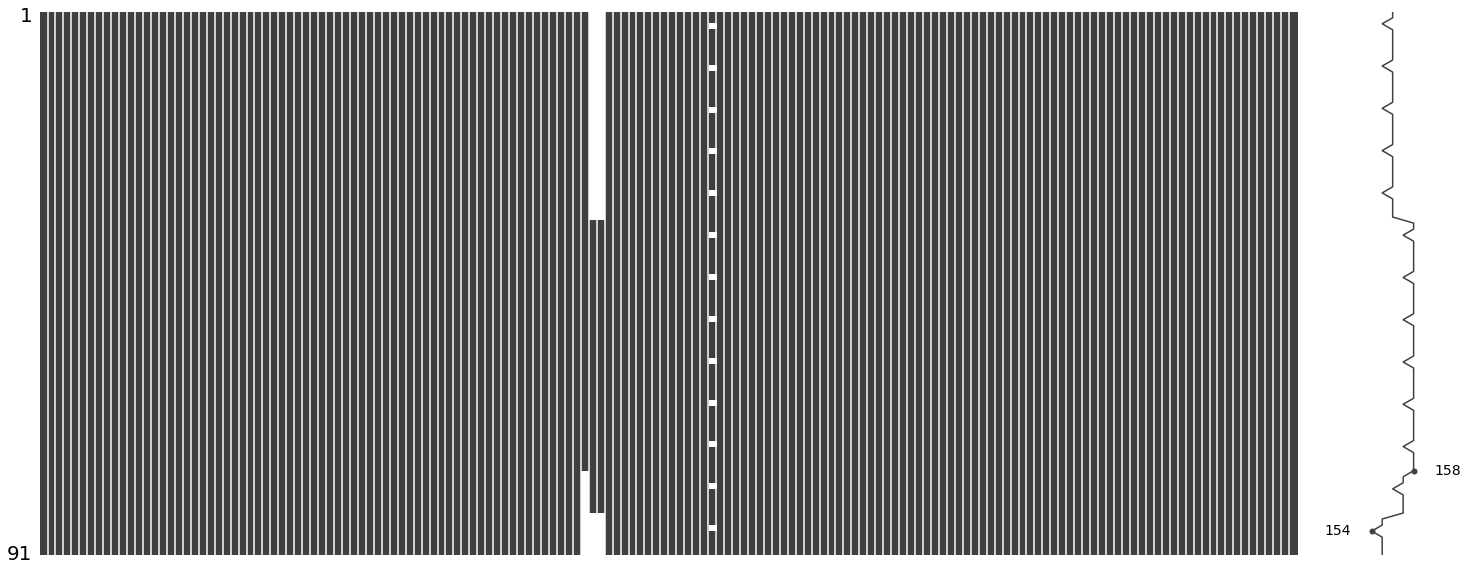

In [15]:
missingno.matrix(dataset_annual)

In [16]:
missing = describe_dataframe(dataset_annual, remove_zeros=True)
missing

,Column,Missing
0,MIO_EUR,15.3846
1,L_TOTAL,46.1538
2,UNL_TOTAL,46.1538
3,lc_prop2_assessment,14.2857


In [17]:
dataset_annual.head(15)

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,0.209542,0.084306,-0.135432,-0.084306,0.210950,0.084331,-0.133873,-0.084331,0.028764,0.022920,0.025596,0.022920,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,19.630667,24.659972,14.601362,10.084537,30.272130,8.925385,10.198012,14.356594,14.611853,11.748092,13.211258,18.716307,19.078873,6.102678,7.184766,9.996880,10.144833,2.327471,70.508041,16.161901,31.948678,420.724039,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN,17366.277778,0,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,98.0,9.0,99.0,30.0,98.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,8.761039,11.164811,14.354265,10.411558,0.225938,-0.128775,0.098342,-0.098342,0.227611,-0.129751,0.098468,-0.098468,0.034440,0.025090,0.025707,0.025707,8.761039,17.323678,28.685148,14.078281,0.226606,-0.164660,0.079341,-0.079341,0.228645,-0.166416,0.078758,-0.078758,0.031283,0.024252,0.023193,0.023193,8.761039,21.197592,31.415197,16.672258,0.222420,-0.171283,0.070905,-0.070905,0.225311,-0.173512,0.070782,-0.070782,0.030175,0.024679,0.023232,0.023232,8.761039,19.630667,31.415197,27.929651,0.209542,-0.135432,0.084306,-0.084306,0.210950,-0.133873,0.084331,-0.084331,0.028764,0.025596,0.022920,0.022920
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,0.127551,0.003880,-0.165458,-0.003880,0.152499,0.014449,-0.175283,-0.014449,0.021217,0.012498,0.015604,0.012498,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,21.213768,26.585228,15.842308,11.503148,32.171296,10.697240,10.758644,16.032804,16.346960,14.091789,14.646375,20.729327,21.147473,7.302691,6.870913,11.336281,11.546448,2.234278,67.672758,15.559771,30.885917,405.531029,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN,22230.111111,0,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,98.0,9.0,99.0,1.0,98.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,10.493728,12.495987,16.066416,10.074423,0.130060,-0.129545,0.028303,-0.028303,0.127362,-0.124802,0.027217,-0.027217,0.024737,0.017251,0.014358,0.014358,10.493728,18.833947,30.252407

In [18]:
dataset_annual.cases.sum()

296

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

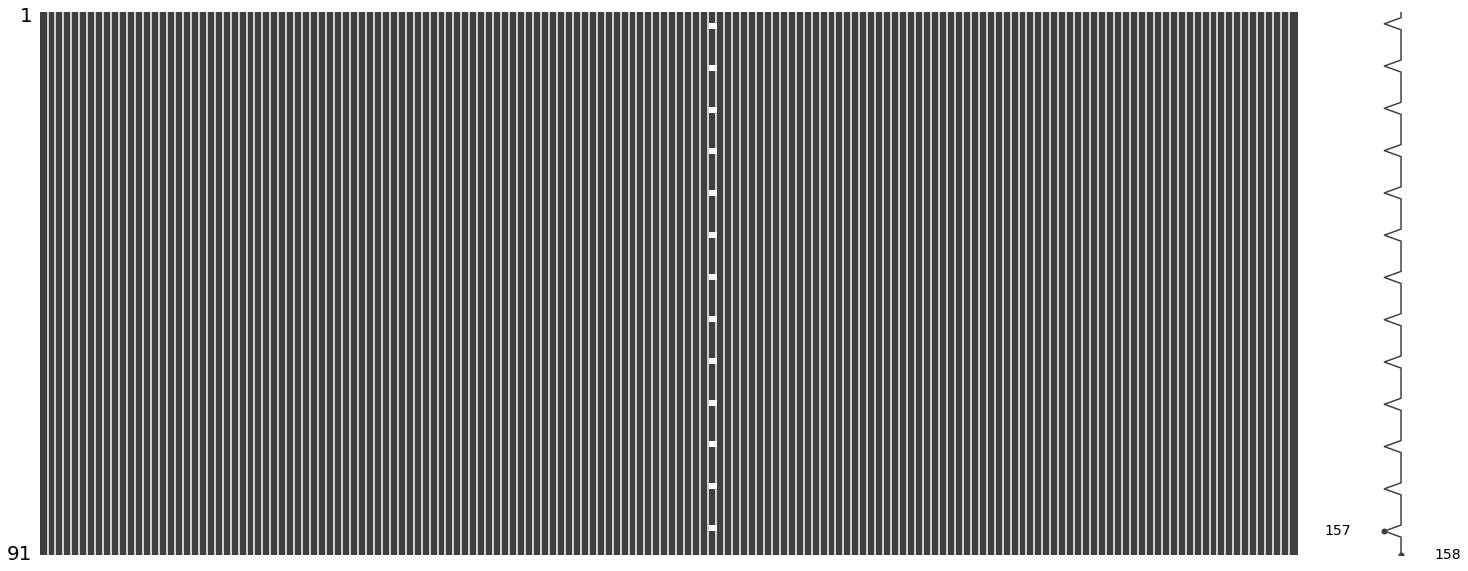

In [22]:
missingno.matrix(dataset_annual, label_rotation=90)

<AxesSubplot:>

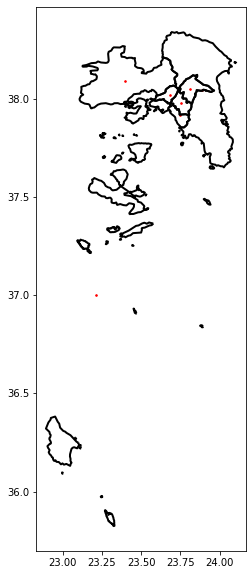

In [23]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_annual[['NUTS3_NAME']], geometry=gpd.points_from_xy(dataset_annual.x, dataset_annual.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [24]:
data_q1 = []
data_q2 = []
data_q3 = []
data_q4 = []

for year in years[1:]:
    for region in nuts3_units:

        df_preceding = dataset_annual.loc[(dataset_annual['year'] == year-1) & (dataset_annual['NUTS3_NAME'] == region)]
        df_current = dataset_annual.loc[(dataset_annual['year'] == year) & (dataset_annual['NUTS3_NAME'] == region)]

        data_q1.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q1': df_current.min_temp_q1.iloc[0],
                        'mean_temp_q1': df_current.mean_temp_q1.iloc[0],
                        'max_temp_q1': df_current.max_temp_q1.iloc[0],
                        'prec_q1': df_current.prec_q1.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q1': df_current.ndvi_q1.iloc[0],
                        'ndwi_q1': df_current.ndwi_q1.iloc[0],
                        'ndmi_q1': df_current.ndmi_q1.iloc[0],
                        'ndbi_q1': df_current.ndbi_q1.iloc[0],
                        'ndvi_mean_q1': df_current.ndvi_mean_q1.iloc[0],
                        'ndwi_mean_q1': df_current.ndwi_mean_q1.iloc[0],
                        'ndmi_mean_q1': df_current.ndmi_mean_q1.iloc[0],
                        'ndbi_mean_q1': df_current.ndbi_mean_q1.iloc[0],
                        'ndvi_std_q1': df_current.ndvi_std_q1.iloc[0],
                        'ndwi_std_q1': df_current.ndwi_std_q1.iloc[0],
                        'ndmi_std_q1': df_current.ndmi_std_q1.iloc[0],
                        'ndbi_std_q1': df_current.ndbi_std_q1.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'qc': df_preceding.qc.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q2.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q2': df_current.min_temp_q2.iloc[0],
                        'mean_temp_q2': df_current.mean_temp_q2.iloc[0],
                        'max_temp_q2': df_current.max_temp_q2.iloc[0],
                        'prec_q2': df_current.prec_q2.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q2': df_current.ndvi_q2.iloc[0],
                        'ndwi_q2': df_current.ndwi_q2.iloc[0],
                        'ndmi_q2': df_current.ndmi_q2.iloc[0],
                        'ndbi_q2': df_current.ndbi_q2.iloc[0],
                        'ndvi_mean_q2': df_current.ndvi_mean_q2.iloc[0],
                        'ndwi_mean_q2': df_current.ndwi_mean_q2.iloc[0],
                        'ndmi_mean_q2': df_current.ndmi_mean_q2.iloc[0],
                        'ndbi_mean_q2': df_current.ndbi_mean_q2.iloc[0],
                        'ndvi_std_q2': df_current.ndvi_std_q2.iloc[0],
                        'ndwi_std_q2': df_current.ndwi_std_q2.iloc[0],
                        'ndmi_std_q2': df_current.ndmi_std_q2.iloc[0],
                        'ndbi_std_q2': df_current.ndbi_std_q2.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'qc': df_preceding.qc.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q3.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q3': df_current.min_temp_q3.iloc[0],
                        'mean_temp_q3': df_current.mean_temp_q3.iloc[0],
                        'max_temp_q3': df_current.max_temp_q3.iloc[0],
                        'prec_q3': df_current.prec_q3.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q3': df_current.ndvi_q3.iloc[0],
                        'ndwi_q3': df_current.ndwi_q3.iloc[0],
                        'ndmi_q3': df_current.ndmi_q3.iloc[0],
                        'ndbi_q3': df_current.ndbi_q3.iloc[0],
                        'ndvi_mean_q3': df_current.ndvi_mean_q3.iloc[0],
                        'ndwi_mean_q3': df_current.ndwi_mean_q3.iloc[0],
                        'ndmi_mean_q3': df_current.ndmi_mean_q3.iloc[0],
                        'ndbi_mean_q3': df_current.ndbi_mean_q3.iloc[0],
                        'ndvi_std_q3': df_current.ndvi_std_q3.iloc[0],
                        'ndwi_std_q3': df_current.ndwi_std_q3.iloc[0],
                        'ndmi_std_q3': df_current.ndmi_std_q3.iloc[0],
                        'ndbi_std_q3': df_current.ndbi_std_q3.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'qc': df_preceding.qc.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q4.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q4': df_current.min_temp_q4.iloc[0],
                        'mean_temp_q4': df_current.mean_temp_q4.iloc[0],
                        'max_temp_q4': df_current.max_temp_q4.iloc[0],
                        'prec_q4': df_current.prec_q4.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q4': df_current.ndvi_q4.iloc[0],
                        'ndwi_q4': df_current.ndwi_q4.iloc[0],
                        'ndmi_q4': df_current.ndmi_q4.iloc[0],
                        'ndbi_q4': df_current.ndbi_q4.iloc[0],
                        'ndvi_mean_q4': df_current.ndvi_mean_q4.iloc[0],
                        'ndwi_mean_q4': df_current.ndwi_mean_q4.iloc[0],
                        'ndmi_mean_q4': df_current.ndmi_mean_q4.iloc[0],
                        'ndbi_mean_q4': df_current.ndbi_mean_q4.iloc[0],
                        'ndvi_std_q4': df_current.ndvi_std_q4.iloc[0],
                        'ndwi_std_q4': df_current.ndwi_std_q4.iloc[0],
                        'ndmi_std_q4': df_current.ndmi_std_q4.iloc[0],
                        'ndbi_std_q4': df_current.ndbi_std_q4.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'qc': df_preceding.qc.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
df_q1 = pd.DataFrame(data_q1)
df_q2 = pd.DataFrame(data_q2)   
df_q3 = pd.DataFrame(data_q3)   
df_q4 = pd.DataFrame(data_q4)   

In [25]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,10.142834,12.225479,21.632204,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.255745,-0.142293,0.107329,-0.107329,0.253581,-0.144536,0.102359,-0.102359,0.036118,0.024477,0.025483,0.025483,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.140,2605.2,3841.2,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,17366.277778,3
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,11.021415,13.184319,22.222381,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.245740,-0.156439,0.090184,-0.090184,0.216751,-0.157282,0.070787,-0.070787,0.024685,0.016912,0.012720,0.012720,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.890,2605.2,3841.2,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,10.862909,12.827836,21.453654,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.214027,-0.102015,0.097905,-0.097905,0.208985,-0.095366,0.098232,-0.098232,0.046665,0.032105,0.029402,0.029402,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.830,2605.2,3841.2,9967.604261,2195.498040,15.0,239.898712,262.905206,194.363331,0.0,2.669538,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,10.805057,12.688842,21.449134,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.224800,-0.150127,0.074458,-0.074458,0.208431,-0.137764,0.072454,-0.072454,0.033418,0.027221,0.023599,0.023599,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.740,2605.2,3841.2,2801.690321,1232.926967,4.0,211.997473,80.771234,191.138144,0.0,3.315736,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,21091.900000,2
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,9.352691,11.222872,22.115978,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.403031,-0.207276,0.160501,-0.160501,0.392773,-0.193846,0.163102,-0.163102,0.034937,0.036822,0.034206,0.034206,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.440,2605.2,3841.2,9160.777000,3472.916707,10.0,260.150015,628.465808,197.888989,0.0,1.047122,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15911.479310,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2022,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,7.671341,9.712128,10.769135,6.919946,20.04

In [26]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,15.666549,26.680944,32.004021,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.253792,-0.170541,0.089725,-0.089725,0.256750,-0.174851,0.087822,-0.087822,0.034767,0.021236,0.023807,0.023807,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.140,2605.2,3841.2,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,17366.277778,3
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,17.273179,28.776593,31.812763,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.190280,-0.167765,0.045024,-0.045024,0.179329,-0.169038,0.035455,-0.035455,0.027723,0.014951,0.014878,0.014878,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.890,2605.2,3841.2,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,16.787929,27.771579,30.887367,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.212636,-0.137840,0.074903,-0.074903,0.206566,-0.133825,0.072684,-0.072684,0.042580,0.028905,0.026604,0.026604,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.830,2605.2,3841.2,9967.604261,2195.498040,15.0,239.898712,262.905206,194.363331,0.0,2.669538,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,16.553775,27.531733,30.516899,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.210187,-0.175619,0.048881,-0.048881,0.200872,-0.168815,0.047033,-0.047033,0.029260,0.021647,0.021251,0.021251,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.740,2605.2,3841.2,2801.690321,1232.926967,4.0,211.997473,80.771234,191.138144,0.0,3.315736,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,21091.900000,2
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,14.531624,25.502082,32.450768,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.397921,-0.253818,0.127502,-0.127502,0.392185,-0.246674,0.128696,-0.128696,0.034678,0.029876,0.033030,0.033030,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.440,2605.2,3841.2,9160.777000,3472.916707,10.0,260.150015,628.465808,197.888989,0.0,1.047122,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15911.479310,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2022,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,7.671341,17.323482,30.179404,11.930259,20

In [27]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,20.170519,31.078387,32.642185,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.247551,-0.182368,0.079455,-0.079455,0.249847,-0.186561,0.077217,-0.077217,0.033705,0.022287,0.023810,0.023810,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.140,2605.2,3841.2,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,17366.277778,3
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,21.932668,33.195161,32.595574,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.174031,-0.178666,0.025206,-0.025206,0.167300,-0.180944,0.017834,-0.017834,0.025586,0.016485,0.014229,0.014229,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.890,2605.2,3841.2,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,21.248946,32.160102,31.582155,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.204773,-0.149678,0.062690,-0.062690,0.199747,-0.147951,0.059373,-0.059373,0.040707,0.028420,0.026886,0.026886,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.830,2605.2,3841.2,9967.604261,2195.498040,15.0,239.898712,262.905206,194.363331,0.0,2.669538,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,21.118014,31.921968,31.206384,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.194478,-0.186140,0.030849,-0.030849,0.188257,-0.182074,0.029487,-0.029487,0.026456,0.021707,0.021393,0.021393,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.740,2605.2,3841.2,2801.690321,1232.926967,4.0,211.997473,80.771234,191.138144,0.0,3.315736,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,21091.900000,2
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,19.117302,30.001501,33.211956,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.366031,-0.272629,0.094886,-0.094886,0.362359,-0.267013,0.096231,-0.096231,0.033897,0.028630,0.032696,0.032696,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.440,2605.2,3841.2,9160.777000,3472.916707,10.0,260.150015,628.465808,197.888989,0.0,1.047122,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15911.479310,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2022,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,7.671341,21.452196,31.996095,14.622342,20

In [28]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,18.388333,31.078387,41.559495,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.236755,-0.160586,0.085082,-0.085082,0.237146,-0.161234,0.084128,-0.084128,0.031998,0.026201,0.025035,0.025035,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.140,2605.2,3841.2,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,17366.277778,3
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,20.020165,33.195161,41.366925,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.157168,-0.158791,0.026042,-0.026042,0.151596,-0.155242,0.023133,-0.023133,0.023500,0.018424,0.014485,0.014485,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.890,2605.2,3841.2,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,19.391282,32.160102,40.157912,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.194791,-0.126242,0.069932,-0.069932,0.185733,-0.121223,0.066190,-0.066190,0.038666,0.030799,0.026883,0.026883,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.830,2605.2,3841.2,9967.604261,2195.498040,15.0,239.898712,262.905206,194.363331,0.0,2.669538,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,19.380928,31.921968,39.513355,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.185945,-0.169934,0.034933,-0.034933,0.176351,-0.162109,0.033773,-0.033773,0.025434,0.024895,0.021924,0.021924,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.740,2605.2,3841.2,2801.690321,1232.926967,4.0,211.997473,80.771234,191.138144,0.0,3.315736,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,21091.900000,2
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,17.538410,30.001501,42.135300,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.343995,-0.254095,0.089446,-0.089446,0.338470,-0.245319,0.091713,-0.091713,0.033233,0.032721,0.033751,0.033751,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.440,2605.2,3841.2,9160.777000,3472.916707,10.0,260.150015,628.465808,197.888989,0.0,1.047122,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15911.479310,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2022,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,7.671341,20.229514,31.996095,26.528293,20

In [29]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

296
296
296
296


In [30]:
df_q1 = convert_multiple_cases(df_q1, target_col='WNV_cases')
df_q2 = convert_multiple_cases(df_q2, target_col='WNV_cases')
df_q3 = convert_multiple_cases(df_q3, target_col='WNV_cases')
df_q4 = convert_multiple_cases(df_q4, target_col='WNV_cases')

In [31]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

296
296
296
296


In [32]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,10.142834,12.225479,21.632204,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.255745,-0.142293,0.107329,-0.107329,0.253581,-0.144536,0.102359,-0.102359,0.036118,0.024477,0.025483,0.025483,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.14,2605.2,3841.2,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,17366.277778,1
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,11.021415,13.184319,22.222381,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.245740,-0.156439,0.090184,-0.090184,0.216751,-0.157282,0.070787,-0.070787,0.024685,0.016912,0.012720,0.012720,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.89,2605.2,3841.2,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,10.862909,12.827836,21.453654,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.214027,-0.102015,0.097905,-0.097905,0.208985,-0.095366,0.098232,-0.098232,0.046665,0.032105,0.029402,0.029402,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.83,2605.2,3841.2,9967.604261,2195.498040,15.0,239.898712,262.905206,194.363331,0.0,2.669538,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,10.805057,12.688842,21.449134,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.224800,-0.150127,0.074458,-0.074458,0.208431,-0.137764,0.072454,-0.072454,0.033418,0.027221,0.023599,0.023599,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.74,2605.2,3841.2,2801.690321,1232.926967,4.0,211.997473,80.771234,191.138144,0.0,3.315736,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,21091.900000,1
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,9.352691,11.222872,22.115978,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.403031,-0.207276,0.160501,-0.160501,0.392773,-0.193846,0.163102,-0.163102,0.034937,0.036822,0.034206,0.034206,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.44,2605.2,3841.2,9160.777000,3472.916707,10.0,260.150015,628.465808,197.888989,0.0,1.047122,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15911.479310,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,2019,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,6.037363,9.769440,13.756352,20.185827,19.416667,19.333

In [33]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,15.666549,26.680944,32.004021,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.253792,-0.170541,0.089725,-0.089725,0.256750,-0.174851,0.087822,-0.087822,0.034767,0.021236,0.023807,0.023807,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.14,2605.2,3841.2,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,17366.277778,1
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,17.273179,28.776593,31.812763,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.190280,-0.167765,0.045024,-0.045024,0.179329,-0.169038,0.035455,-0.035455,0.027723,0.014951,0.014878,0.014878,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.89,2605.2,3841.2,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,16.787929,27.771579,30.887367,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.212636,-0.137840,0.074903,-0.074903,0.206566,-0.133825,0.072684,-0.072684,0.042580,0.028905,0.026604,0.026604,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.83,2605.2,3841.2,9967.604261,2195.498040,15.0,239.898712,262.905206,194.363331,0.0,2.669538,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,16.553775,27.531733,30.516899,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.210187,-0.175619,0.048881,-0.048881,0.200872,-0.168815,0.047033,-0.047033,0.029260,0.021647,0.021251,0.021251,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.74,2605.2,3841.2,2801.690321,1232.926967,4.0,211.997473,80.771234,191.138144,0.0,3.315736,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,21091.900000,1
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,14.531624,25.502082,32.450768,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.397921,-0.253818,0.127502,-0.127502,0.392185,-0.246674,0.128696,-0.128696,0.034678,0.029876,0.033030,0.033030,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.44,2605.2,3841.2,9160.777000,3472.916707,10.0,260.150015,628.465808,197.888989,0.0,1.047122,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15911.479310,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,2019,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,6.037363,15.340361,27.383099,27.901461,19.416667,19.3

In [34]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,20.170519,31.078387,32.642185,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.247551,-0.182368,0.079455,-0.079455,0.249847,-0.186561,0.077217,-0.077217,0.033705,0.022287,0.023810,0.023810,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.14,2605.2,3841.2,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,17366.277778,1
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,21.932668,33.195161,32.595574,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.174031,-0.178666,0.025206,-0.025206,0.167300,-0.180944,0.017834,-0.017834,0.025586,0.016485,0.014229,0.014229,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.89,2605.2,3841.2,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,21.248946,32.160102,31.582155,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.204773,-0.149678,0.062690,-0.062690,0.199747,-0.147951,0.059373,-0.059373,0.040707,0.028420,0.026886,0.026886,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.83,2605.2,3841.2,9967.604261,2195.498040,15.0,239.898712,262.905206,194.363331,0.0,2.669538,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,21.118014,31.921968,31.206384,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.194478,-0.186140,0.030849,-0.030849,0.188257,-0.182074,0.029487,-0.029487,0.026456,0.021707,0.021393,0.021393,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.74,2605.2,3841.2,2801.690321,1232.926967,4.0,211.997473,80.771234,191.138144,0.0,3.315736,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,21091.900000,1
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,19.117302,30.001501,33.211956,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.366031,-0.272629,0.094886,-0.094886,0.362359,-0.267013,0.096231,-0.096231,0.033897,0.028630,0.032696,0.032696,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.44,2605.2,3841.2,9160.777000,3472.916707,10.0,260.150015,628.465808,197.888989,0.0,1.047122,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15911.479310,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,2019,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,6.037363,19.538373,29.479852,29.582993,19.416667,19.3

In [35]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,18.388333,31.078387,41.559495,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.236755,-0.160586,0.085082,-0.085082,0.237146,-0.161234,0.084128,-0.084128,0.031998,0.026201,0.025035,0.025035,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.14,2605.2,3841.2,14600.648385,292.022047,2.0,182.342684,228.131012,182.543294,0.0,41.287682,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,17366.277778,1
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,20.020165,33.195161,41.366925,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.157168,-0.158791,0.026042,-0.026042,0.151596,-0.155242,0.023133,-0.023133,0.023500,0.018424,0.014485,0.014485,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.89,2605.2,3841.2,7655.023708,1575.096836,1.0,173.398830,66.866135,178.818040,0.0,5.887334,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,19.391282,32.160102,40.157912,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.194791,-0.126242,0.069932,-0.069932,0.185733,-0.121223,0.066190,-0.066190,0.038666,0.030799,0.026883,0.026883,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.83,2605.2,3841.2,9967.604261,2195.498040,15.0,239.898712,262.905206,194.363331,0.0,2.669538,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,19.380928,31.921968,39.513355,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.185945,-0.169934,0.034933,-0.034933,0.176351,-0.162109,0.033773,-0.033773,0.025434,0.024895,0.021924,0.021924,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.74,2605.2,3841.2,2801.690321,1232.926967,4.0,211.997473,80.771234,191.138144,0.0,3.315736,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,0.0,21091.900000,1
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,17.538410,30.001501,42.135300,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.343995,-0.254095,0.089446,-0.089446,0.338470,-0.245319,0.091713,-0.091713,0.033233,0.032721,0.033751,0.033751,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.44,2605.2,3841.2,9160.777000,3472.916707,10.0,260.150015,628.465808,197.888989,0.0,1.047122,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,0.0,15911.479310,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,2019,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,6.037363,18.609159,29.479852,50.595849,19.416667,19.3

In [36]:
df_q1.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2011_2022.csv", encoding = enc, index = False)
df_q2.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q2_2011_2022.csv", encoding = enc, index = False)
df_q3.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q3_2011_2022.csv", encoding = enc, index = False)
df_q4.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2011_2022.csv", encoding = enc, index = False)